# Adversarial Evaluation: Noise, Brightness & Contrast Robustness

In [1]:
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import balanced_accuracy_score

# 1. Load Model
NUM_CLASSES = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load("fids30_classifier_30cls_b0.pth", map_location=device))
model = model.to(device)
model.eval()

# 2. Load Test Data
config = timm.data.resolve_model_data_config(model)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

class_names = test_ds.classes
print(f"Device: {device}")
print(f"Test samples: {len(test_ds)}, Classes: {len(class_names)}")

Device: cuda
Test samples: 195, Classes: 30


In [2]:
# 3. Collect all test images and labels into tensors
all_images = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        all_images.append(images)
        all_labels.append(labels)

all_images = torch.cat(all_images)  # (N, C, H, W)
all_labels = torch.cat(all_labels)  # (N,)
print(f"Collected {len(all_images)} test images")

Collected 195 test images


In [3]:
# 4. Define noise levels and evaluate
noise_stddevs = np.linspace(0.0, 0.5, 15)
balanced_accs = []

torch.manual_seed(42)

for std in noise_stddevs:
    preds = []
    noisy_loader = DataLoader(
        torch.utils.data.TensorDataset(all_images, all_labels),
        batch_size=32, shuffle=False
    )
    with torch.no_grad():
        for images, labels in noisy_loader:
            images = images.to(device)
            noise = torch.randn_like(images) * std
            noisy_images = images + noise
            outputs = model(noisy_images)
            preds.extend(outputs.argmax(dim=1).cpu().numpy())

    bal_acc = balanced_accuracy_score(all_labels.numpy(), preds)
    balanced_accs.append(bal_acc)
    print(f"Noise std={std:.2f}  Balanced Acc={bal_acc:.2%}")

Noise std=0.00  Balanced Acc=80.99%
Noise std=0.04  Balanced Acc=78.68%
Noise std=0.07  Balanced Acc=78.13%
Noise std=0.11  Balanced Acc=76.87%
Noise std=0.14  Balanced Acc=75.74%
Noise std=0.18  Balanced Acc=67.35%
Noise std=0.21  Balanced Acc=60.85%
Noise std=0.25  Balanced Acc=55.24%
Noise std=0.29  Balanced Acc=38.04%
Noise std=0.32  Balanced Acc=29.79%
Noise std=0.36  Balanced Acc=22.94%
Noise std=0.39  Balanced Acc=15.43%
Noise std=0.43  Balanced Acc=10.40%
Noise std=0.46  Balanced Acc=7.74%
Noise std=0.50  Balanced Acc=5.03%


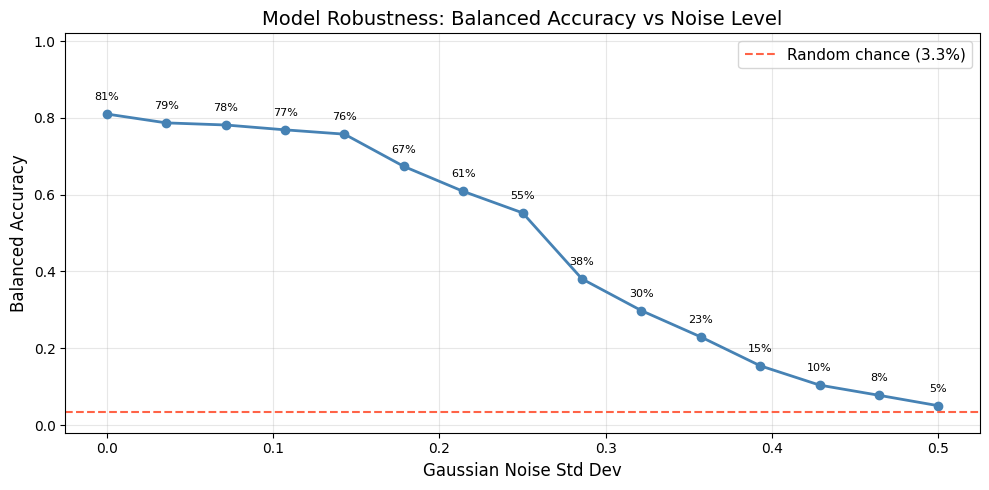

In [4]:
# 5. Plot performance degradation
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(noise_stddevs, balanced_accs, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.set_xlabel("Gaussian Noise Std Dev", fontsize=12)
ax.set_ylabel("Balanced Accuracy", fontsize=12)
ax.set_title("Model Robustness: Balanced Accuracy vs Noise Level", fontsize=14)
ax.set_ylim(-0.02, 1.02)
ax.axhline(y=1/NUM_CLASSES, color='tomato', linestyle='--', label=f'Random chance ({1/NUM_CLASSES:.1%})')
for i, (x, y) in enumerate(zip(noise_stddevs, balanced_accs)):
    ax.annotate(f"{y:.0%}", (x, y), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=8)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

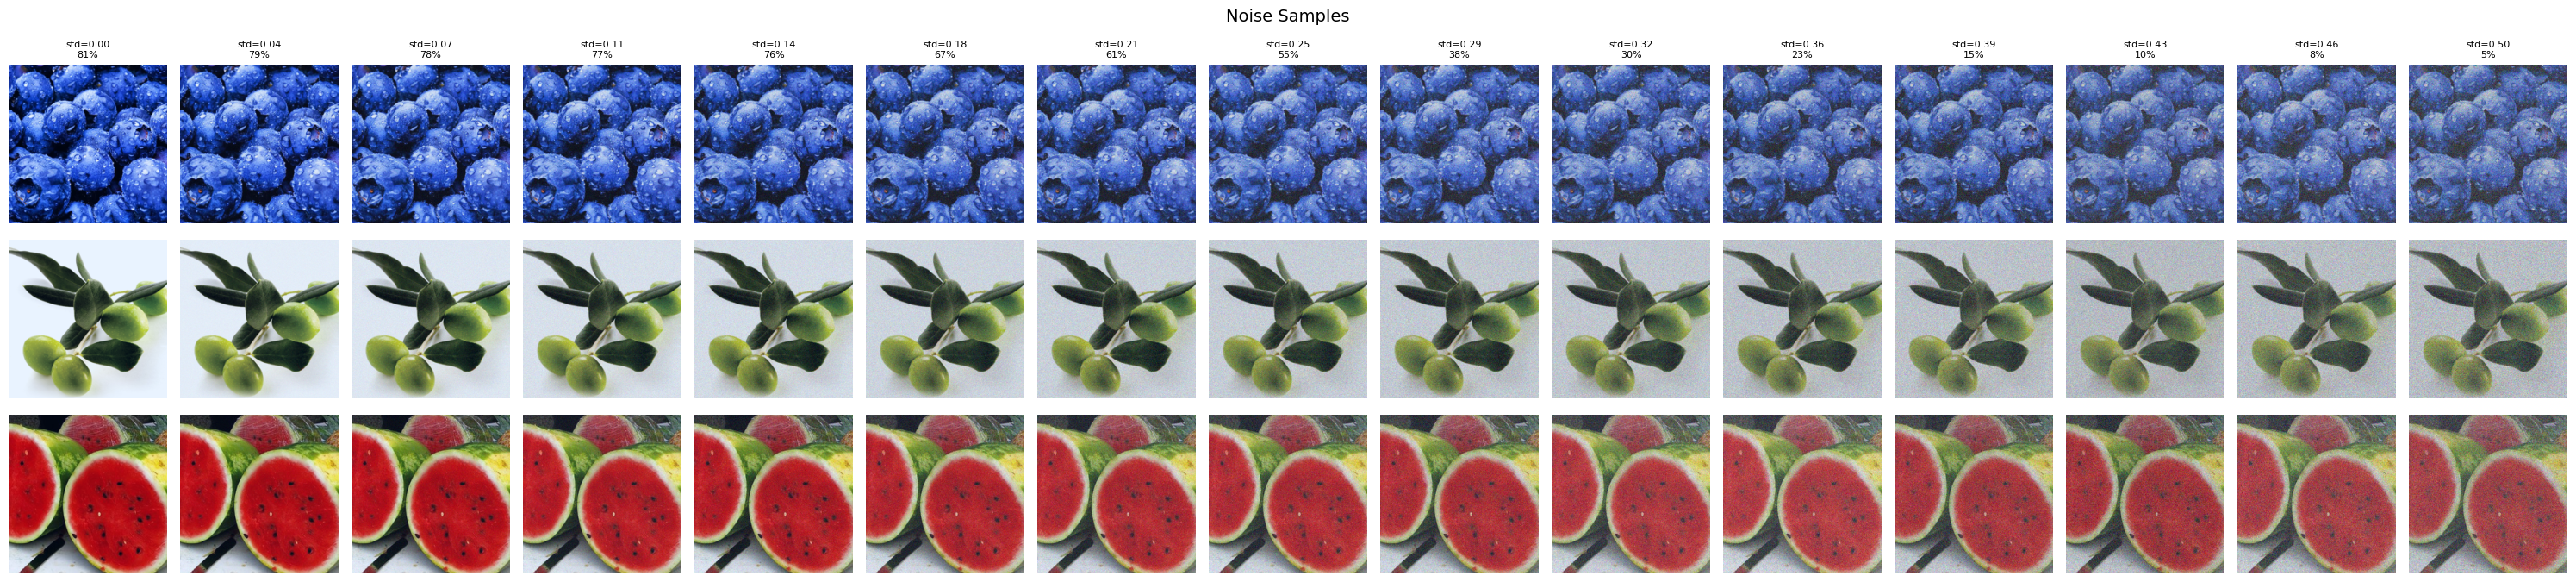

In [5]:
def denorm_image(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

rng = np.random.default_rng()
noise_sample_indices = rng.choice(len(all_images), size=3, replace=False)

fig, axes = plt.subplots(3, 15, figsize=(30, 7))

torch.manual_seed(42)

for col, std in enumerate(noise_stddevs):
    for row, idx in enumerate(noise_sample_indices):
        img = all_images[idx]
        noisy_img = img + torch.randn_like(img) * std
        axes[row, col].imshow(denorm_image(noisy_img))
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f"std={std:.2f}\n{balanced_accs[col]:.0%}", fontsize=8)

fig.suptitle("Noise Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
def evaluate_perturbation(all_images, all_labels, perturb_fn, levels, level_name):
    """Evaluate balanced accuracy across perturbation levels.
    perturb_fn(images, level) -> perturbed images tensor on same device.
    """
    accs = []
    loader = DataLoader(
        torch.utils.data.TensorDataset(all_images, all_labels),
        batch_size=32, shuffle=False
    )
    for lvl in levels:
        preds = []
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(device)
                perturbed = perturb_fn(images, lvl)
                outputs = model(perturbed)
                preds.extend(outputs.argmax(dim=1).cpu().numpy())
        bal_acc = balanced_accuracy_score(all_labels.numpy(), preds)
        accs.append(bal_acc)
        print(f"{level_name}={lvl:.2f}  Balanced Acc={bal_acc:.2%}")
    return accs


def plot_degradation(levels, accs, xlabel, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(levels, accs, 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Balanced Accuracy", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_ylim(-0.02, 1.02)
    ax.axhline(y=1/NUM_CLASSES, color='tomato', linestyle='--', label=f'Random chance ({1/NUM_CLASSES:.1%})')
    for x, y in zip(levels, accs):
        ax.annotate(f"{y:.0%}", (x, y), textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=8)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_sample_grid(all_images, sample_indices, levels, accs, perturb_fn_cpu, title, level_fmt):
    fig, axes = plt.subplots(3, 15, figsize=(30, 7))
    for col, lvl in enumerate(levels):
        for row, idx in enumerate(sample_indices):
            img = all_images[idx]
            perturbed = perturb_fn_cpu(img.unsqueeze(0), lvl).squeeze(0)
            axes[row, col].imshow(denorm_image(perturbed))
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(f"{level_fmt(lvl)}\n{accs[col]:.0%}", fontsize=8)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## Brightness

In [7]:
# Brightness: add a constant offset to all pixels (in normalized space)
# Levels go from -1.5 (very dark) through 0.0 (original) to +1.5 (very bright)
brightness_levels = np.linspace(-1.5, 1.5, 15)

def brightness_perturb(images, offset):
    return images + offset

brightness_accs = evaluate_perturbation(
    all_images, all_labels, brightness_perturb, brightness_levels, "Brightness offset"
)

Brightness offset=-1.50  Balanced Acc=29.44%
Brightness offset=-1.29  Balanced Acc=40.13%


Brightness offset=-1.07  Balanced Acc=50.23%
Brightness offset=-0.86  Balanced Acc=66.80%
Brightness offset=-0.64  Balanced Acc=76.64%
Brightness offset=-0.43  Balanced Acc=80.74%
Brightness offset=-0.21  Balanced Acc=79.26%
Brightness offset=0.00  Balanced Acc=80.99%
Brightness offset=0.21  Balanced Acc=80.91%
Brightness offset=0.43  Balanced Acc=80.05%
Brightness offset=0.64  Balanced Acc=64.58%
Brightness offset=0.86  Balanced Acc=34.97%
Brightness offset=1.07  Balanced Acc=19.12%
Brightness offset=1.29  Balanced Acc=14.88%
Brightness offset=1.50  Balanced Acc=8.87%


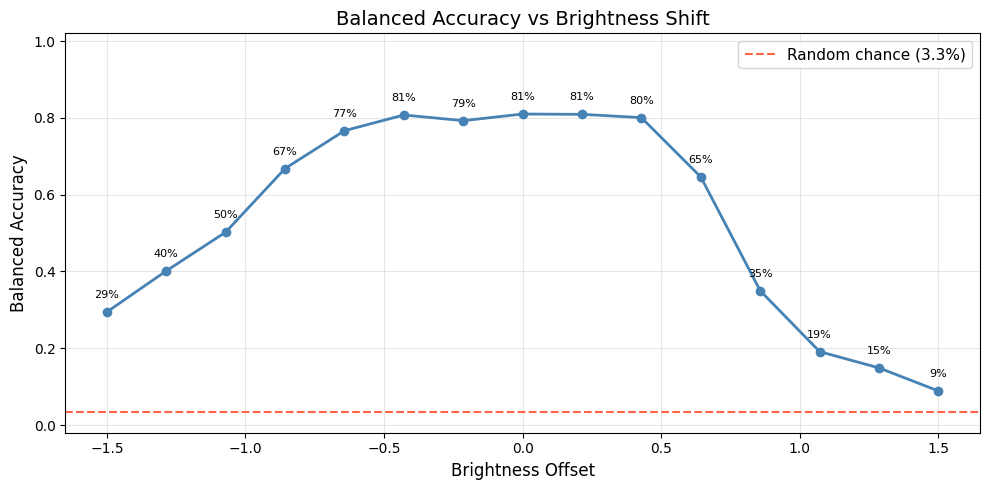

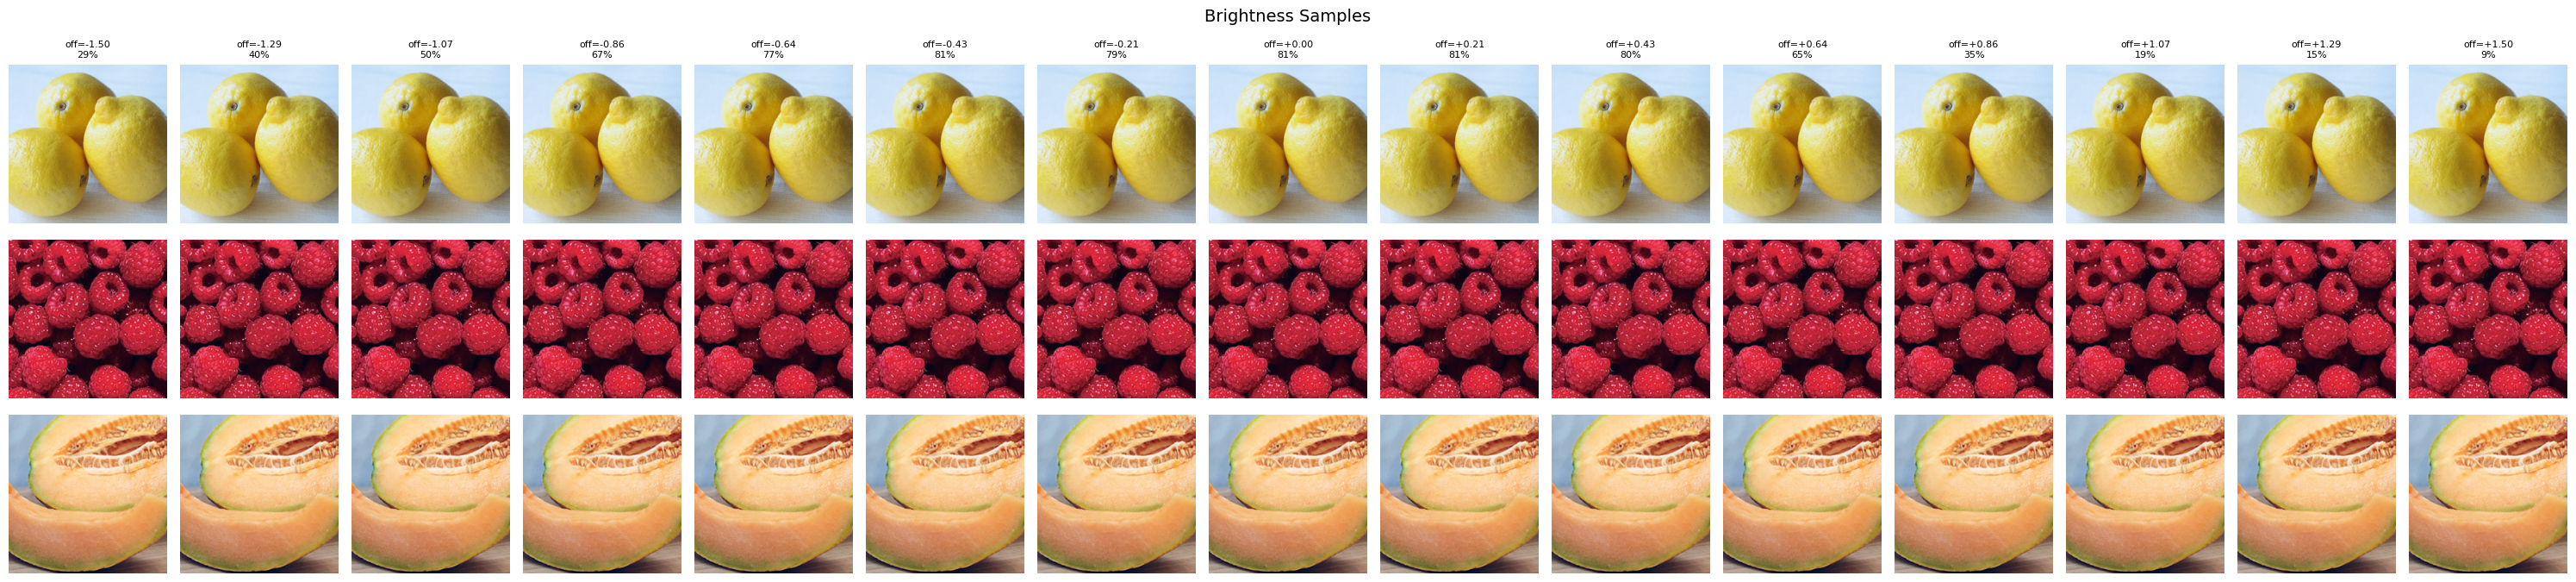

In [8]:
plot_degradation(brightness_levels, brightness_accs,
                 "Brightness Offset", "Balanced Accuracy vs Brightness Shift")

brightness_sample_indices = rng.choice(len(all_images), size=3, replace=False)
plot_sample_grid(all_images, brightness_sample_indices, brightness_levels, brightness_accs,
                 lambda img, offset: img + offset,
                 "Brightness Samples",
                 lambda lvl: f"off={lvl:+.2f}")

## Contrast

In [9]:
# Contrast: scale pixels around per-image mean
# 0.0 = flat gray, 1.0 = original, 2.5 = very high contrast
contrast_levels = np.linspace(0.33, 2.5, 15)

def contrast_perturb(images, factor):
    mean = images.mean(dim=(2, 3), keepdim=True)
    return mean + (images - mean) * factor

contrast_accs = evaluate_perturbation(
    all_images, all_labels, contrast_perturb, contrast_levels, "Contrast factor"
)

Contrast factor=0.33  Balanced Acc=73.38%
Contrast factor=0.48  Balanced Acc=77.20%
Contrast factor=0.64  Balanced Acc=79.15%
Contrast factor=0.79  Balanced Acc=79.21%
Contrast factor=0.95  Balanced Acc=80.32%
Contrast factor=1.10  Balanced Acc=80.77%
Contrast factor=1.26  Balanced Acc=81.05%
Contrast factor=1.42  Balanced Acc=68.67%
Contrast factor=1.57  Balanced Acc=47.55%
Contrast factor=1.73  Balanced Acc=28.49%
Contrast factor=1.88  Balanced Acc=16.48%
Contrast factor=2.04  Balanced Acc=10.71%
Contrast factor=2.19  Balanced Acc=3.37%
Contrast factor=2.35  Balanced Acc=3.96%
Contrast factor=2.50  Balanced Acc=2.48%


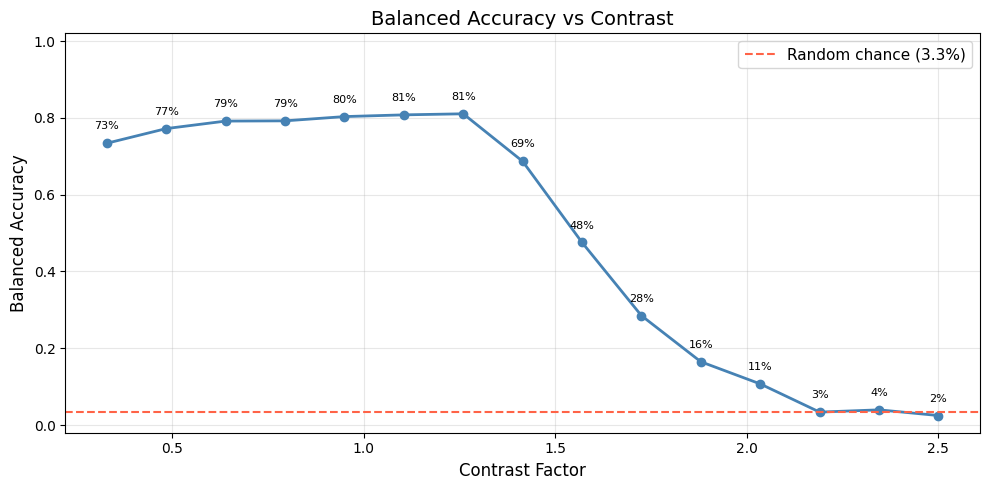

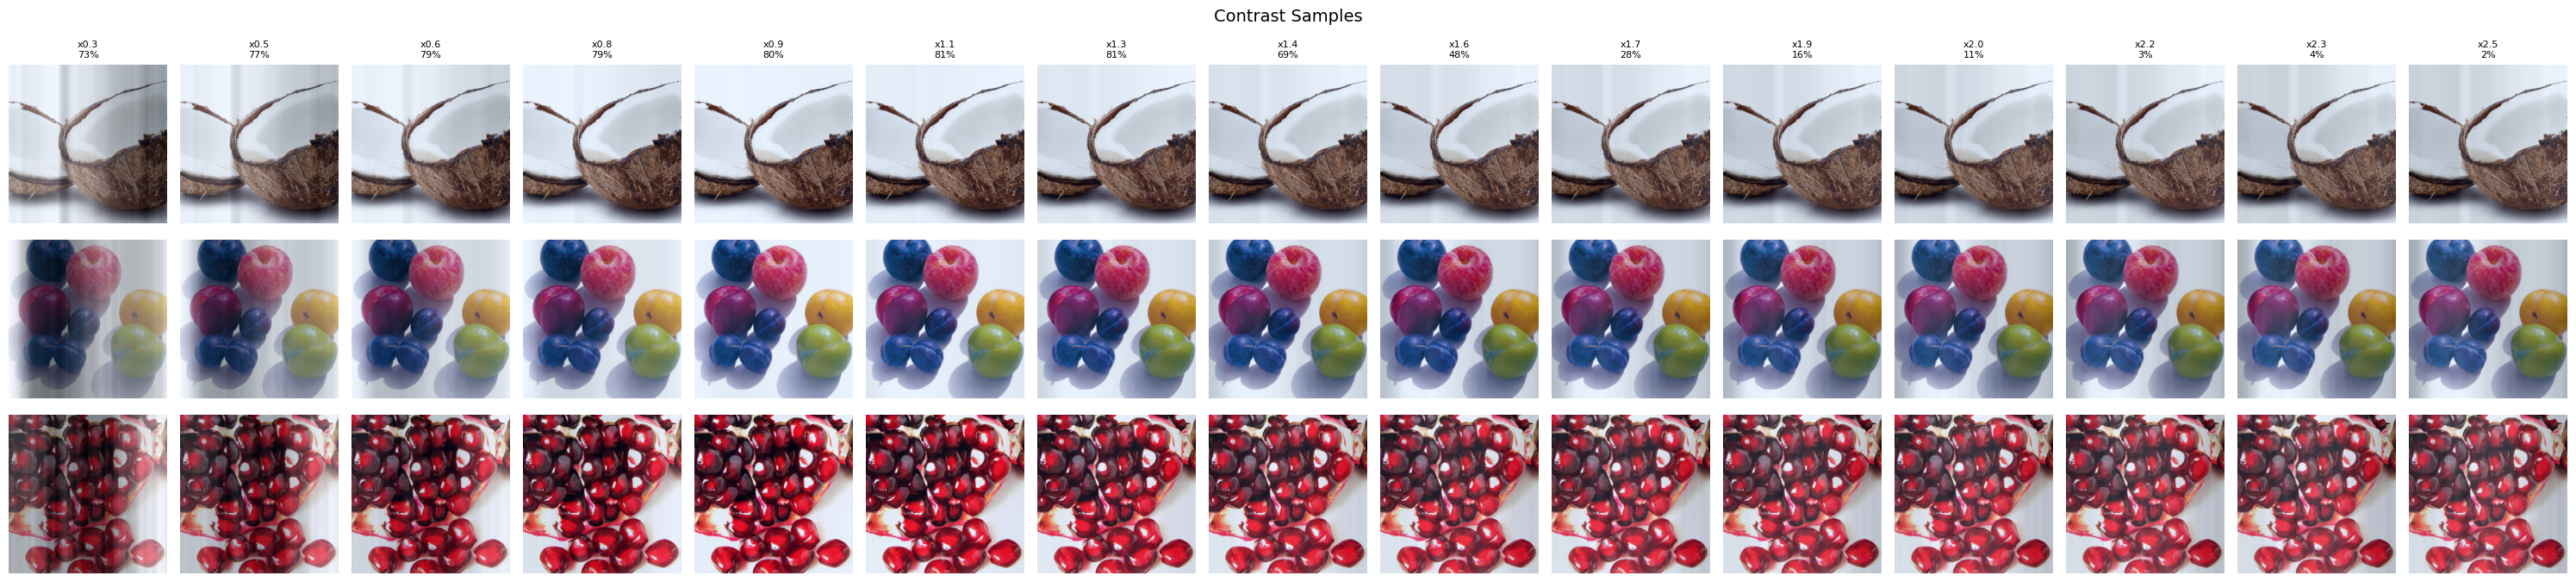

In [10]:
plot_degradation(contrast_levels, contrast_accs,
                 "Contrast Factor", "Balanced Accuracy vs Contrast")

contrast_sample_indices = rng.choice(len(all_images), size=3, replace=False)
plot_sample_grid(all_images, contrast_sample_indices, contrast_levels, contrast_accs,
                 lambda img, factor: img.mean(dim=(1, 2), keepdim=True) + (img - img.mean(dim=(1, 2), keepdim=True)) * factor,
                 "Contrast Samples",
                 lambda lvl: f"x{lvl:.1f}")